In [38]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import requests
from pathlib import Path

# ============================
# 0) Paths & Configs
# ============================
BASE_DIR = Path.cwd()

RESTROOM_CSV_PATH = BASE_DIR / "Public_Restrooms.csv"
TRACT_SHP_PATH = BASE_DIR / "tl_2023_36_tract" / "tl_2023_36_tract.shp"

CENSUS_API_KEY = "094639c98364a4419c71c18045f3c739f9284b2b"
ACS_YEAR = "2023"
ACS_DATASET = "acs/acs5"
TABLE_POP = "B01003_001E"  # Total population

NYC_COUNTIES = {"005", "047", "061", "081", "085"}
TARGET_EPSG = 2263  # feet-based projection for NYC


# ============================
# 1) Load restroom locations
# ============================
rest_df = pd.read_csv(RESTROOM_CSV_PATH)

# Clean column names: strip -> lowercase -> replace spaces with "_"
rest_df.columns = (
    rest_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

# Latitude/longitude columns (fixed for this dataset)
lat_col = "latitude"
lon_col = "longitude"

rest_gdf = gpd.GeoDataFrame(
    rest_df,
    geometry=gpd.points_from_xy(rest_df[lon_col], rest_df[lat_col]),
    crs="EPSG:4326"
)


# ============================
# 2) Load Census tract geometries
# ============================
tracts = gpd.read_file(TRACT_SHP_PATH)

# Filter NY State (36) and NYC counties only
tracts = tracts[(tracts["STATEFP"] == "36") & (tracts["COUNTYFP"].isin(NYC_COUNTIES))].copy()

# Create GEOID
tracts["GEOID"] = tracts["STATEFP"] + tracts["COUNTYFP"] + tracts["TRACTCE"]

# Detect tract name column
if "NAMELSAD" in tracts.columns:
    name_col = "NAMELSAD"
elif "NAMELSAD20" in tracts.columns:
    name_col = "NAMELSAD20"
else:
    name_col = "NAME"

tracts["tract_name"] = tracts[name_col]

# Add borough name column
borough_map = {
    "005": "Bronx",
    "047": "Brooklyn",
    "061": "Manhattan",
    "081": "Queens",
    "085": "Staten Island"
}
tracts["borough"] = tracts["COUNTYFP"].map(borough_map)


# ============================
# 3) Retrieve population from Census API
# ============================
base_url = f"https://api.census.gov/data/{ACS_YEAR}/{ACS_DATASET}"

params = {
    "get": f"{TABLE_POP},NAME",
    "for": "tract:*",
    "in": "state:36",
    "key": CENSUS_API_KEY
}

resp = requests.get(base_url, params=params, timeout=60)
resp.raise_for_status()
data = resp.json()

cols = data[0]
rows = data[1:]
pop_df = pd.DataFrame(rows, columns=cols)

# Convert population to numeric
pop_df[TABLE_POP] = pd.to_numeric(pop_df[TABLE_POP], errors="coerce").fillna(0).astype(int)

# Create GEOID
pop_df["GEOID"] = pop_df["state"] + pop_df["county"] + pop_df["tract"]

# Keep only NYC counties
pop_df = pop_df[pop_df["county"].isin(NYC_COUNTIES)].copy()

# Rename population column
pop_df.rename(columns={TABLE_POP: "population"}, inplace=True)

# Keep only necessary columns
pop_df = pop_df[["GEOID", "population"]].copy()


# ============================
# 4) Merge population into tract data
# ============================
tracts = tracts.merge(pop_df, on="GEOID", how="left")
tracts["population"] = tracts["population"].fillna(0).astype(int)

# Convert CRS for distance/area calculations
tracts = tracts.to_crs(TARGET_EPSG)
rest_gdf = rest_gdf.to_crs(TARGET_EPSG)


# ============================
# 4-1) Area and population density
# ============================
# EPSG:2263 area unit: ft² → convert to km²
# 1 ft² = 0.09290304 m²; 1 km² = 1,000,000 m²
SQFT_TO_SQKM = 0.09290304 / 1_000_000

tracts["area_km2"] = tracts.geometry.area * SQFT_TO_SQKM
tracts["pop_density"] = tracts["population"] / tracts["area_km2"].replace(0, np.nan)


# ============================
# 5) Distance to nearest restroom
# ============================
tracts["centroid"] = tracts.geometry.centroid

centroids_gdf = gpd.GeoDataFrame(
    tracts[["GEOID"]].copy(),
    geometry=tracts["centroid"],
    crs=tracts.crs
)

nearest = gpd.sjoin_nearest(
    centroids_gdf,
    rest_gdf,
    how="left",
    distance_col="nearest_restroom_dist"
)[["GEOID", "nearest_restroom_dist"]]

tracts = tracts.merge(nearest, on="GEOID", how="left")


# ============================
# 6) Restroom count per tract
# ============================
# Spatial join: assign each restroom point to the tract polygon it falls within
rest_with_tract = gpd.sjoin(
    rest_gdf,
    tracts[["GEOID", "geometry"]],
    how="left",
    predicate="within"
)

# Count number of restrooms per tract (GEOID)
rest_count = rest_with_tract.groupby("GEOID").size().reset_index(name="restroom_count")

# Merge restroom count into tracts GeoDataFrame
tracts = tracts.merge(rest_count, on="GEOID", how="left")

# Replace NaN (no restrooms in tract) with 0
tracts["restroom_count"] = tracts["restroom_count"].fillna(0).astype(int)

# ============================
# 7) People per restroom (shortage indicator)
# ============================
# Add 1 to restroom_count to avoid division by zero;
# tracts with zero restrooms will still have very large values.
tracts["people_per_restroom"] = tracts["population"] / (tracts["restroom_count"] + 1)

# Log-transform to reduce skewness
tracts["log_people_per_restroom"] = np.log1p(tracts["people_per_restroom"])


# ============================
# 8) Priority Score calculation (final version)
# ============================
# Indicators used:
#  - log_pop_density        : higher → more crowded
#  - log_nearest_dist       : higher → farther from nearest restroom
#  - log_people_per_restroom: higher → fewer restrooms per person

# Log-transform base indicators
tracts["log_pop_density"] = np.log1p(tracts["pop_density"])
tracts["log_nearest_dist"] = np.log1p(tracts["nearest_restroom_dist"])

# Standardize each log indicator (z-score)
for col in ["log_pop_density", "log_nearest_dist", "log_people_per_restroom"]:
    tracts[col + "_z"] = (tracts[col] - tracts[col].mean()) / tracts[col].std()

# Final Priority Score: equal-weight average of the three standardized indicators
tracts["Priority_Score"] = (
    tracts["log_pop_density_z"] +
    tracts["log_nearest_dist_z"] +
    tracts["log_people_per_restroom_z"]
) / 3

# Define Priority Class (top 20% as high-priority tracts)
threshold = tracts["Priority_Score"].quantile(0.8)
tracts["Priority_Class"] = (tracts["Priority_Score"] >= threshold).astype(int)


# ============================
# 9) Export output CSV
# ============================
out_cols = [
    "GEOID", "borough", "tract_name",
    "population", "area_km2", "pop_density",
    "restroom_count", "people_per_restroom",
    "nearest_restroom_dist",
    "Priority_Score", "Priority_Class"
]

tracts[out_cols].to_csv(BASE_DIR / "NYC_Public_Restroom_Priority_Score.csv", index=False)

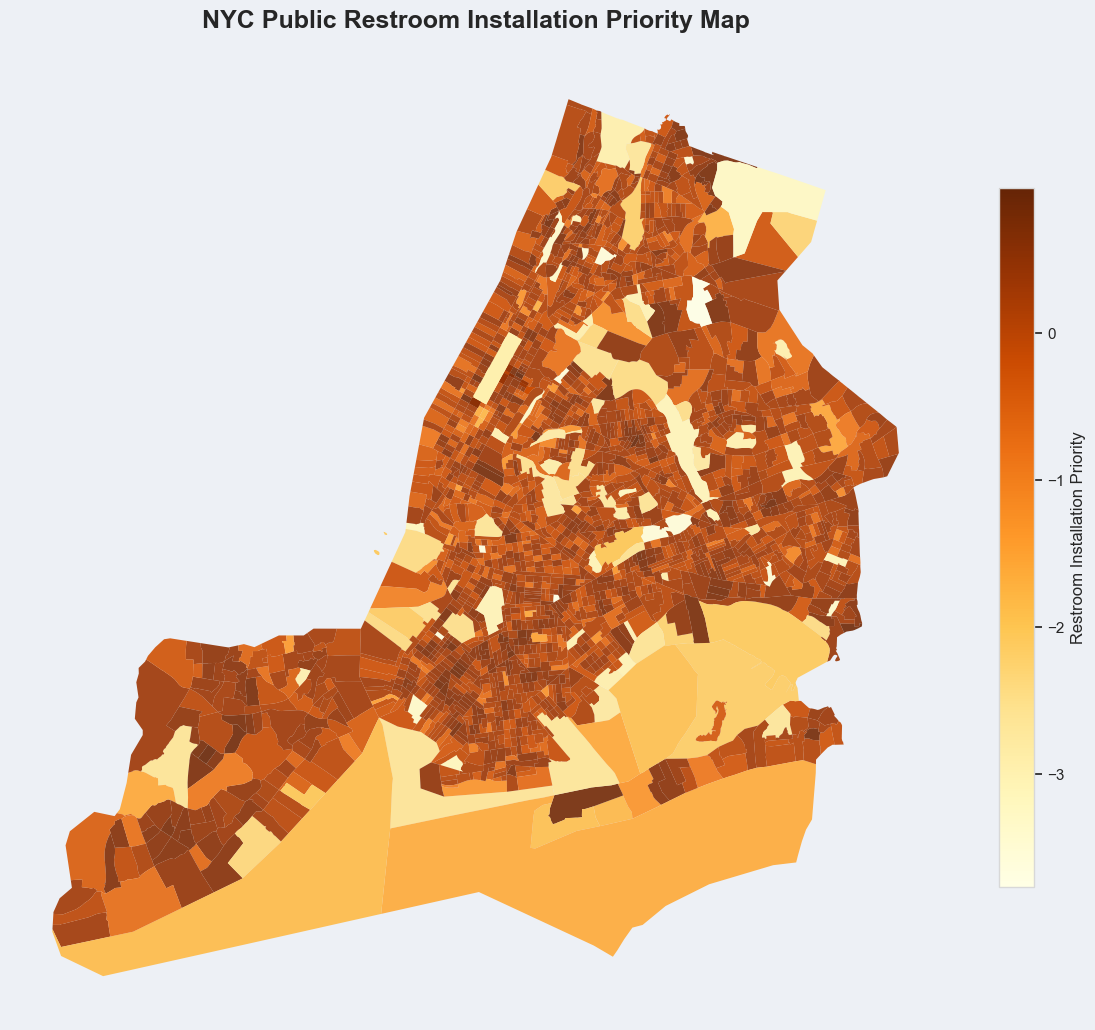

In [39]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(12, 12))

cmap = mpl.cm.YlOrBr

tracts.plot(
    column="Priority_Score",
    cmap=cmap,
    linewidth=0,
    edgecolor="none",
    alpha=0.9,
    legend=True,
    legend_kwds={
        "label": "Restroom Installation Priority",
        "shrink": 0.6,
        "orientation": "vertical"
    },
    ax=ax
)

ax.set_facecolor("#f7f7f7")

ax.set_title(
    "NYC Public Restroom Installation Priority Map",
    fontsize=18, fontweight="bold",
    pad=20
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [40]:
import pandas as pd

df = pd.read_csv("NYC_Public_Restroom_Priority_Score.csv")

# Filter high-priority tracts (Priority_Class == 1)
top_priority = (
    df[df["Priority_Class"] == 1]
    .sort_values("Priority_Score", ascending=False)
)

top_priority.head()

,GEOID,borough,tract_name,population,area_km2,pop_density,restroom_count,people_per_restroom,nearest_restroom_dist,Priority_Score,Priority_Class
701,36061014602,Manhattan,Census Tract 146.02,8543,0.109171,78253.618920,0,8543.0,2262.520477,0.979245,1
1929,36085027705,Staten Island,Census Tract 277.05,6094,0.531533,11464.944134,0,6094.0,4390.006230,0.925639,1
95,36081046700,Queens,Census Tract 467,7445,0.141858,52482.013246,0,7445.0,2444.987240,0.924856,1
770,36081066403,Queens,Census Tract 664.03,5857,0.362183,16171.385568,0,5857.0,3490.735538,0.860687,1
659,36085027302,Staten Island,Census Tract 273.02,4419,1.021155,4327.451286,0,4419.0,5808.150168,0.840500,1


In [41]:
# Numeric columns for descriptive statistics 
num_cols = [
    "population",
    "area_km2",
    "pop_density",
    "restroom_count",
    "people_per_restroom",
    "nearest_restroom_dist",
    "Priority_Score",
    "Priority_Class",
]

tracts[num_cols].describe()

,population,area_km2,pop_density,restroom_count,people_per_restroom,nearest_restroom_dist,Priority_Score,Priority_Class
count,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2.336000e+03,2336.000000
mean,3658.389127,0.525718,19004.781220,0.483305,2963.955678,1391.895717,-7.208845e-16,0.200342
std,2024.206162,3.386466,14245.347272,1.541343,1825.341694,1063.074548,6.865950e-01,0.400342
min,0.000000,0.038659,0.000000,0.000000,0.000000,22.232585,-3.764891e+00,0.000000
25%,2262.000000,0.152911,8800.432294,0.000000,1735.375000,761.251278,-1.472598e-01,0.000000
50%,3431.000000,0.185752,16236.748729,0.000000,2682.500000,1195.735362,1.704914e-01,0.000000
75%,4779.250000,0.326609,25785.633288,1.000000,3923.250000,1758.482534,3.785453e-01,0.000000
max,16684.000000,130.802132,110669.923816,42.000000,16684.000000,19831.423120,9.792449e-01,1.000000


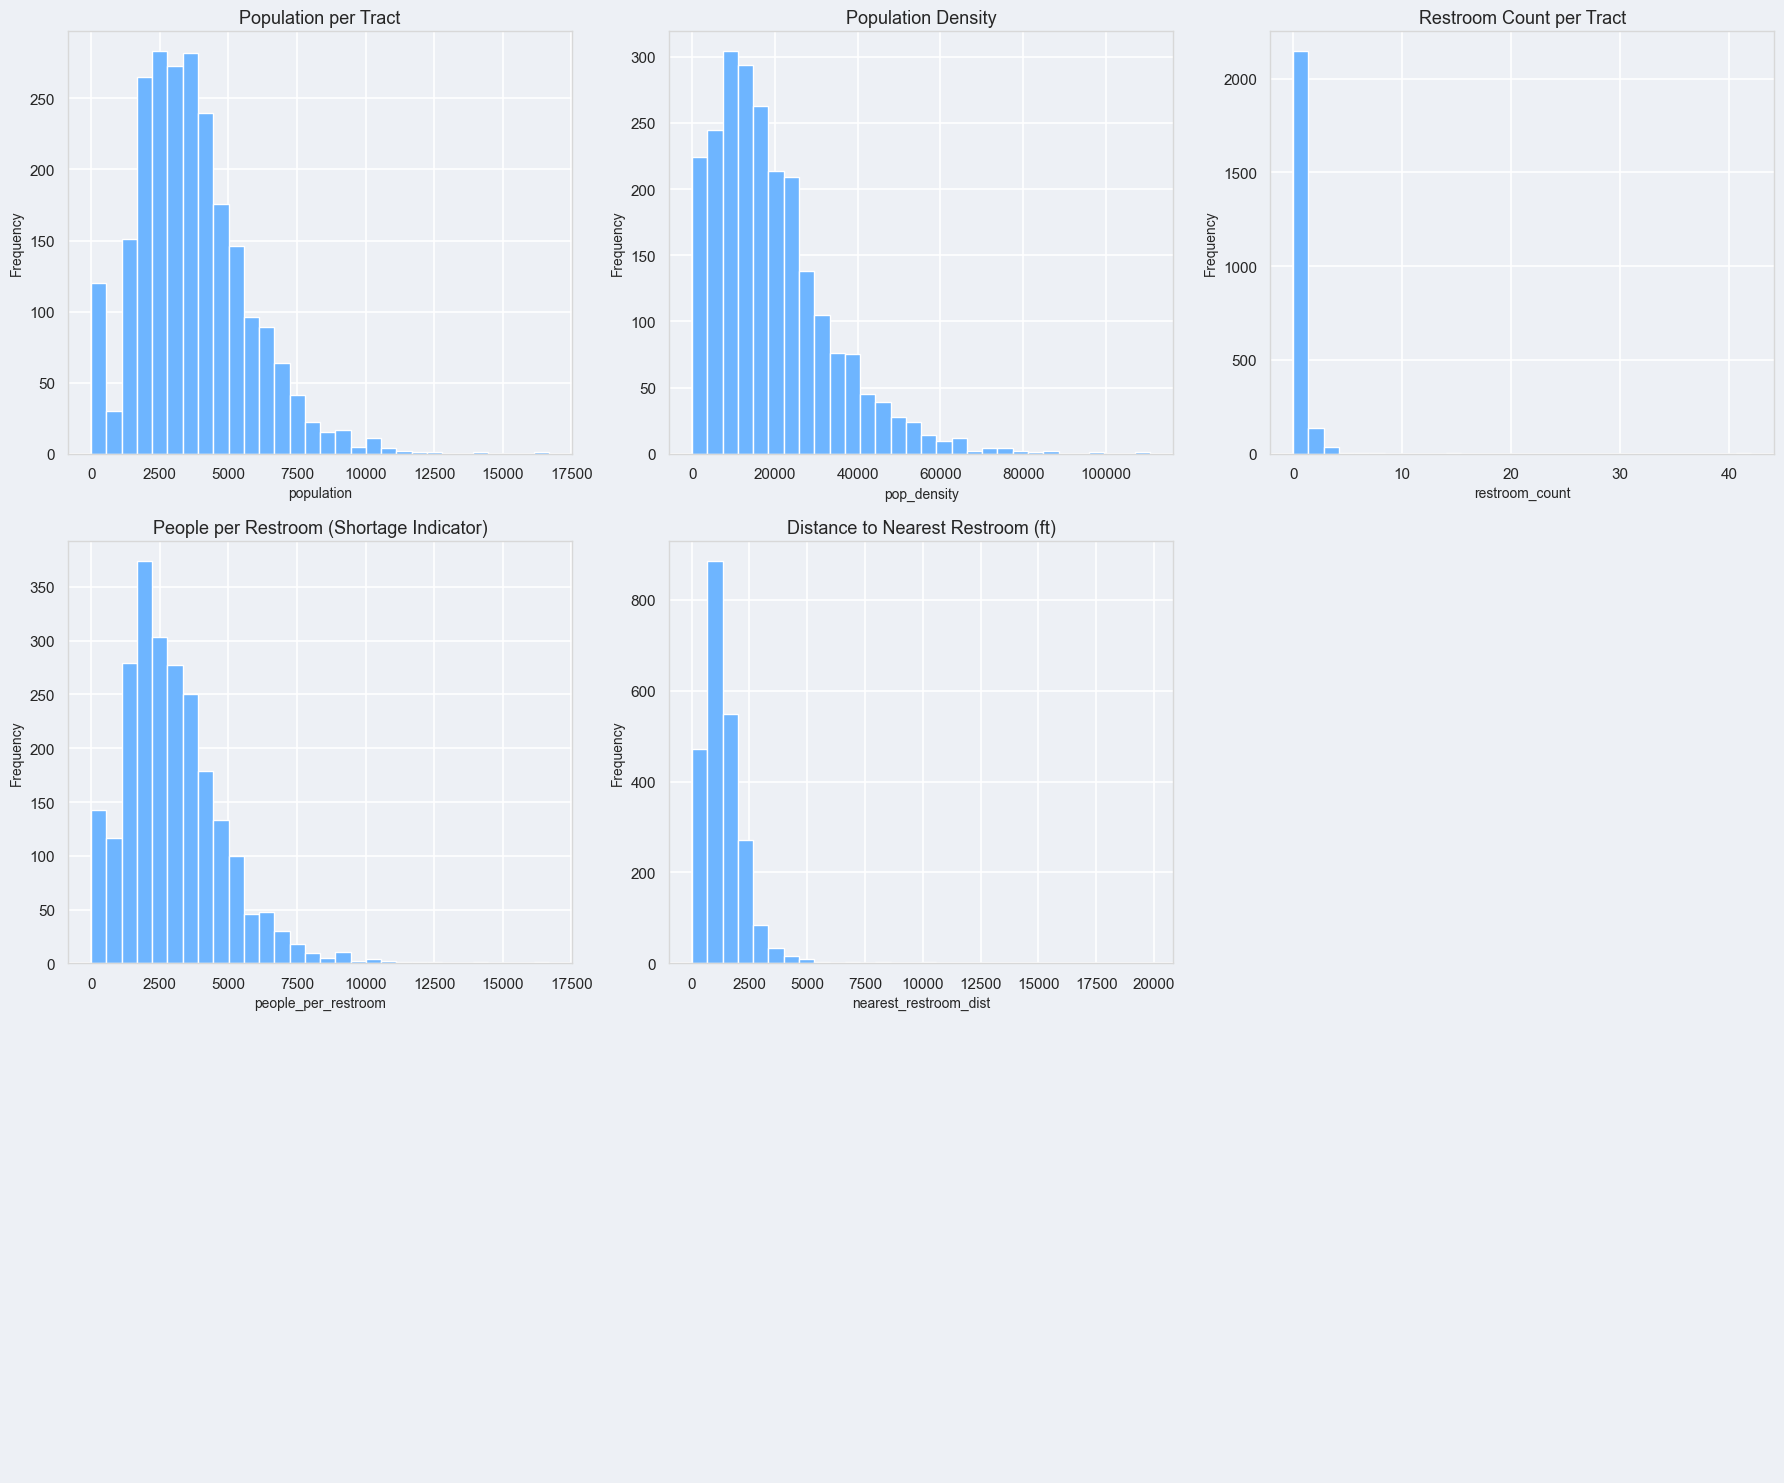

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "#edf0f5",
    "axes.facecolor": "#edf0f5",
    "grid.color": "white",
    "grid.linewidth": 1.2,
    "axes.edgecolor": "#d8d8d8",
    "axes.linewidth": 1.0,
})

vars_hist = [
    "population",
    "pop_density",
    "restroom_count",
    "people_per_restroom",
    "nearest_restroom_dist",
]

titles_hist = [
    "Population per Tract",
    "Population Density",
    "Restroom Count per Tract",
    "People per Restroom (Shortage Indicator)",
    "Distance to Nearest Restroom (ft)",
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(vars_hist, titles_hist)):
    axes[i].hist(tracts[col].dropna(), bins=30, color="#6eb5ff", edgecolor="white")
    axes[i].set_title(title, fontsize=13)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

for j in range(len(vars_hist), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

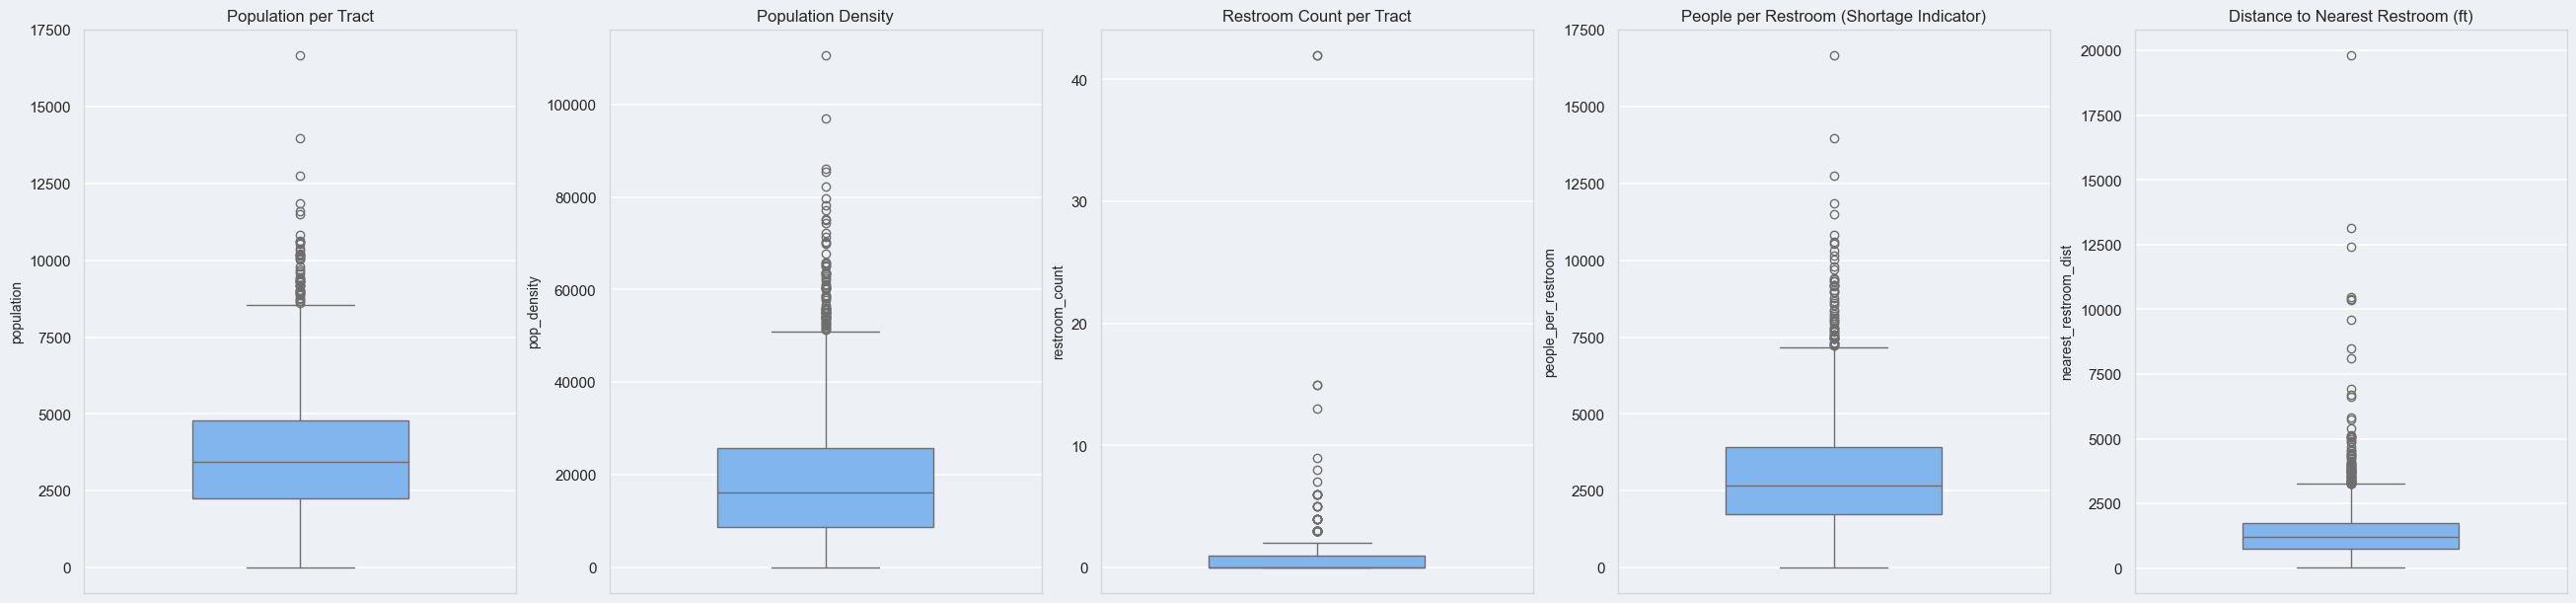

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "#edf0f5",
    "axes.facecolor": "#edf0f5",
    "grid.color": "white",
    "grid.linewidth": 1.2,
    "axes.edgecolor": "#d8d8d8",
    "axes.linewidth": 1.0,
})

vars_box = [
    "population",
    "pop_density",
    "restroom_count",
    "people_per_restroom",
    "nearest_restroom_dist",
]

titles_box = [
    "Population per Tract",
    "Population Density",
    "Restroom Count per Tract",
    "People per Restroom (Shortage Indicator)",
    "Distance to Nearest Restroom (ft)",
]

fig, axes = plt.subplots(1, len(vars_box), figsize=(26, 6), constrained_layout=True)

for i, (col, title) in enumerate(zip(vars_box, titles_box)):
    sns.boxplot(y=tracts[col].dropna(), ax=axes[i], color="#6eb5ff", width=0.5)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylabel(col, fontsize=10)

plt.show()

In [44]:
outliers = tracts[tracts["restroom_count"] > 20].copy()
print("Census Tracts with Unusually High Restroom Counts (>20):")
display(outliers[["GEOID", "borough", "tract_name", "restroom_count"]].drop_duplicates())

Census Tracts with Unusually High Restroom Counts (>20):


,GEOID,borough,tract_name,restroom_count
2025,36061014300,Manhattan,Census Tract 143,42


In [45]:
pip install mapclassify

Note: you may need to restart the kernel to use updated packages.


In [46]:
import geopandas as gpd
import folium

# ============================================================
# 1. Prepare the three groups of polygons
# ============================================================

# Outlier tract(s) with unusually high restroom count (42+ restrooms)
outliers = tracts[tracts["restroom_count"] >= 42].copy()

# Top 5 census tracts recommended for new restroom installation
top5 = (
    tracts[tracts["Priority_Class"] == 1]               # select high-priority tracts
    .sort_values("Priority_Score", ascending=False)     # sort by priority score
    .head(5)                                            # keep top 5
    .copy()
)

# List of attributes to show in tooltip for ALL layers
tooltip_cols = [
    "GEOID",
    "tract_name",
    "borough",
    "population",
    "area_km2",
    "pop_density",
    "nearest_restroom_dist",
    "restroom_count",
    "people_per_restroom",
    "log_pop_density",
    "log_nearest_dist",
    "log_people_per_restroom",
    "Priority_Score",
    "Priority_Class",
]


# ============================================================
# 2. Base map: All census tracts in dark gray
# ============================================================

# Plot all tracts as the background layer
m = tracts.explore(
    color="#555555",                 # border color (dark gray)
    style_kwds={
        "fillColor": "#B0B0B0",      # polygon fill color
        "fillOpacity": 0.5,
        "weight": 0.6,               # border thickness
    },
    tooltip=tooltip_cols,            # show full tract information
    name="All census tracts",
)


# ============================================================
# 3. Add restroom-count outliers (blue polygons)
# ============================================================

outliers.explore(
    m=m,
    color="#1f77b4",                 # blue border & fill
    style_kwds={
        "fillColor": "#1f77b4",
        "fillOpacity": 0.9,
        "weight": 2.0,
    },
    tooltip=tooltip_cols,            # same tooltip fields
    name="Restroom count outlier (42+ restrooms)",
)


# ============================================================
# 4. Add top 5 high-priority tracts (red polygons)
# ============================================================

top5.explore(
    m=m,
    color="#d62728",                 # red border & fill
    style_kwds={
        "fillColor": "#d62728",
        "fillOpacity": 0.9,
        "weight": 2.0,
    },
    tooltip=tooltip_cols,            # same tooltip fields
    name="Top 5 priority tracts",
)


# ============================================================
# 5. Add layer control and render map
# ============================================================

folium.LayerControl().add_to(m)
m

=== Top 5 Priority Tracts vs Overall NYC Average (Priority Score Not Included as Metric) ===
                       overall_mean     top5_mean  ratio_top5_to_overall
population              3658.389127   6471.600000               1.768975
pop_density            19004.781220  32539.882631               1.712195
nearest_restroom_dist   1391.895717   3679.279931               2.643359
restroom_count             0.483305      0.000000               0.000000
people_per_restroom     2963.955678   6471.600000               2.183433


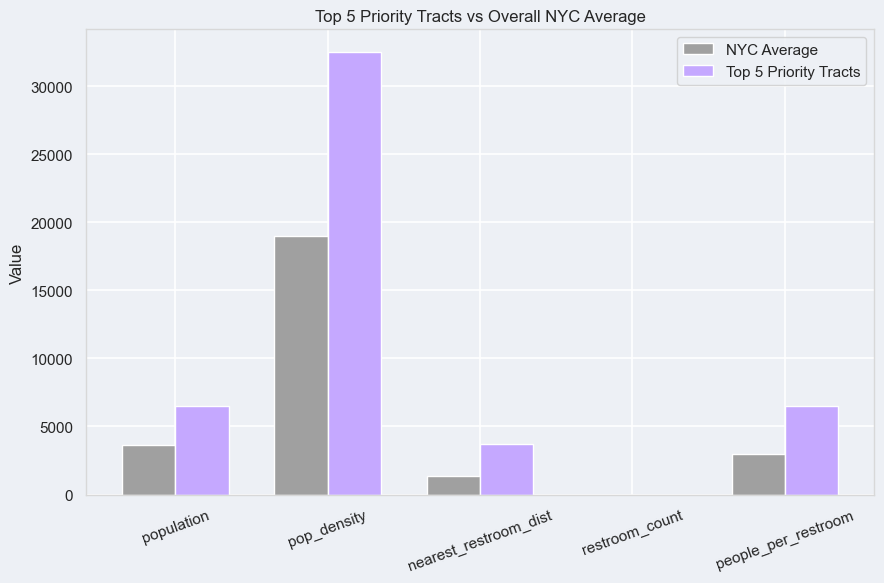

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

top5 = tracts.sort_values("Priority_Score", ascending=False).head(5).copy()

metrics = [
    "population",
    "pop_density",
    "nearest_restroom_dist",
    "restroom_count",
    "people_per_restroom",
]

overall_mean = tracts[metrics].mean()
top5_mean = top5[metrics].mean()

compare_df = pd.DataFrame({
    "overall_mean": overall_mean,
    "top5_mean": top5_mean,
})
compare_df["ratio_top5_to_overall"] = compare_df["top5_mean"] / compare_df["overall_mean"]

print("=== Top 5 Priority Tracts vs Overall NYC Average (Priority Score Not Included as Metric) ===")
print(compare_df)

fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(metrics))
width = 0.35

overall_color = "#A0A0A0"
top5_color = "#C5A8FF"

ax.bar(x - width/2, overall_mean, width, label="NYC Average", color=overall_color)
ax.bar(x + width/2, top5_mean, width, label="Top 5 Priority Tracts", color=top5_color)

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20)
ax.set_ylabel("Value")
ax.set_title("Top 5 Priority Tracts vs Overall NYC Average")
ax.legend()

plt.tight_layout()
plt.show()

In [48]:
corr1 = tracts["pop_density"].corr(tracts["restroom_count"])
print("Correlation: Population Density vs Restroom Count =", corr1)

Correlation: Population Density vs Restroom Count = -0.11646692333024272


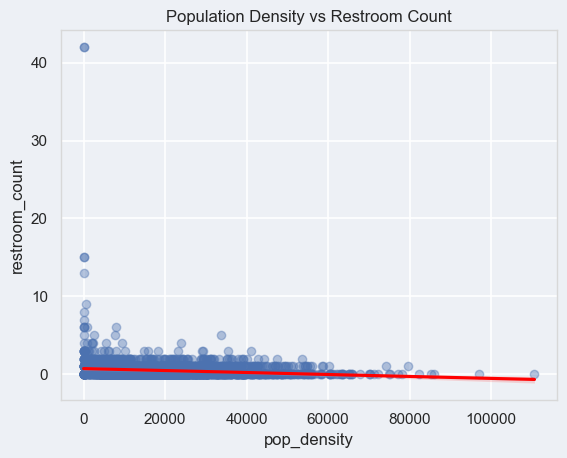

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x="pop_density", y="restroom_count", data=tracts,
            scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
plt.title("Population Density vs Restroom Count")
plt.show()

In [50]:
corr2 = tracts["restroom_count"].corr(tracts["nearest_restroom_dist"])
print("Correlation: Restroom Count vs Nearest Restroom Distance =", corr2)

Correlation: Restroom Count vs Nearest Restroom Distance = -0.1604951060096921


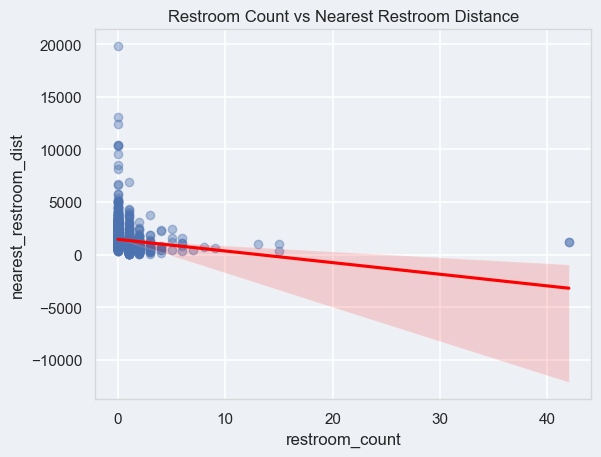

In [51]:
sns.regplot(x="restroom_count", y="nearest_restroom_dist", data=tracts,
            scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
plt.title("Restroom Count vs Nearest Restroom Distance")
plt.show()